# OHBM poster figures


## Simulated data

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fl_prog.utils.constants import DNAME_LATEST
from fl_prog.utils.io import DEFAULT_DPATH_DATA, DEFAULT_DPATH_RESULTS

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["svg.fonttype"] = "none"
sns.set_theme("poster", style="ticks")


def plot_simulated_data(tag, ax, with_legend=False):

    # TAG = "000_overlap"
    # tag = "000percent_3sites_50subjects_14"
    # TAG = "0percent_3sites_50subjects_1"
    # TAG = "iid"
    # TAG = "non_overlapping_t0"
    # TAG = "unequal_sigma"

    TIME_LABEL = "Time"
    BIOMARKER_LABEL = "Biomarker value"
    N_SUBJECTS = 3  # number of subjects per site to plot

    # dname_data_date = DNAME_LATEST
    # dname_results_date = DNAME_LATEST

    dname_data_date = "2026_02_17"
    dname_results_date = "2026_02_17"

    data_dir = DEFAULT_DPATH_DATA / dname_data_date / tag
    results_dir = DEFAULT_DPATH_RESULTS / dname_results_date / tag

    fpath_json_data = data_dir / f"{tag}.json"
    json_data = json.loads(fpath_json_data.read_text())
    print(f"fpath_json_data: {str(fpath_json_data)}")

    try:
        fpath_json_results = results_dir / f"{tag}-estimated_params.json"
        results_dict = json.loads(fpath_json_results.read_text())
        print(f"fpath_json_results: {str(fpath_json_results)}")
    except FileNotFoundError:
        print("Results not available")

    n_biomarkers = json_data["settings"]["n_biomarkers"]

    params = json_data["params"]
    k_values = np.array(params["k_values"])
    x0_values = np.array(params["x0_values"])
    vertical_shifts = np.array(params.get("vertical_shifts", [0] * n_biomarkers))
    scaling_factors = np.array(params.get("scaling_factors", [1] * n_biomarkers))
    time_shifts = np.concatenate(params["time_shifts"])
    sigmas = params["sigmas"]

    n_sites = len(json_data["settings"]["n_subjects_all"])

    df = pd.concat(
        {
            i + 1: pd.read_csv(data_dir / f"{tag}-{i+1}.tsv", sep="\t")
            for i in range(n_sites)
        },
        axis="index",
        names=["site", "tmp"],
    )
    df = df.reset_index(level="tmp", drop=True).reset_index()
    # df = pd.read_csv(data_dir / f"{TAG}-merged.tsv", sep="\t")

    n_subjects_per_site = {}
    for i_subject, (subject, df_subject) in enumerate(df.groupby("subject")):

        site = df_subject["site"].unique().item()
        if site not in n_subjects_per_site:
            n_subjects_per_site[site] = 0

        if n_subjects_per_site[site] >= N_SUBJECTS:
            continue

        for i_biomarker, biomarker in enumerate(json_data["cols"]["cols_biomarker"]):
            ax.plot(
                (
                    df_subject[json_data["cols"]["col_timepoint"]]
                    + time_shifts[i_subject]
                    # if i_ax == 0
                    # else df_subject[json_data["cols"]["col_timepoint"]]
                ),
                df_subject[biomarker],
                marker="oXxp*"[site - 1],
                color=f"C{i_biomarker}",
                # alpha=0.1,
                alpha=0.3,
                markersize=10,
                # label=f"Site {site}",
            )
        n_subjects_per_site[site] += 1

    for i_biomarker, (k, x0, vertical_shift, scaling_factor) in enumerate(
        zip(k_values, x0_values, vertical_shifts, scaling_factors)
    ):
        t = np.linspace(0, 1, 100)
        y = 1 / (1 + np.exp(-k * (t - x0))) * scaling_factor + vertical_shift
        ax.plot(t, y, color=f"C{i_biomarker}", linestyle="--", alpha=1, linewidth=2)

    if with_legend:
        from matplotlib.lines import Line2D

        handles = [
            Line2D(
                [0],
                [0],
                marker="oXxp*"[site],
                linestyle="None",
                color="0.5",
                markerfacecolor="black",
                markersize=8,
                label=f"Site {site+1}",
            )
            for site in range(len(n_subjects_per_site))
        ]

        ax.legend(
            handles=handles,
            fontsize="xx-small",
            handlelength=0.5,
            frameon=False,
            loc="lower right",
            borderpad=0.1,
        )

    ax.set_xlabel(TIME_LABEL)
    ax.set_ylabel(BIOMARKER_LABEL)
    ax.set_yticks([0, 0.5, 1], ["0", "", "1"])

    ax.spines[["top", "right"]].set_visible(False)

fpath_json_data: /data/origami/michelle/projects/fl-prog/data/2026_02_17/100percent_3sites_50subjects_14/100percent_3sites_50subjects_14.json
fpath_json_results: /data/origami/michelle/projects/fl-prog/results/2026_02_17/100percent_3sites_50subjects_14/100percent_3sites_50subjects_14-estimated_params.json
fpath_json_data: /data/origami/michelle/projects/fl-prog/data/2026_02_17/050percent_3sites_50subjects_14/050percent_3sites_50subjects_14.json
fpath_json_results: /data/origami/michelle/projects/fl-prog/results/2026_02_17/050percent_3sites_50subjects_14/050percent_3sites_50subjects_14-estimated_params.json
fpath_json_data: /data/origami/michelle/projects/fl-prog/data/2026_02_17/000percent_3sites_50subjects_14/000percent_3sites_50subjects_14.json
fpath_json_results: /data/origami/michelle/projects/fl-prog/results/2026_02_17/000percent_3sites_50subjects_14/000percent_3sites_50subjects_14-estimated_params.json
XLIM=(-0.05, 1.05)
YLIM=(-0.26390034400000445, 1.1959118913944633)


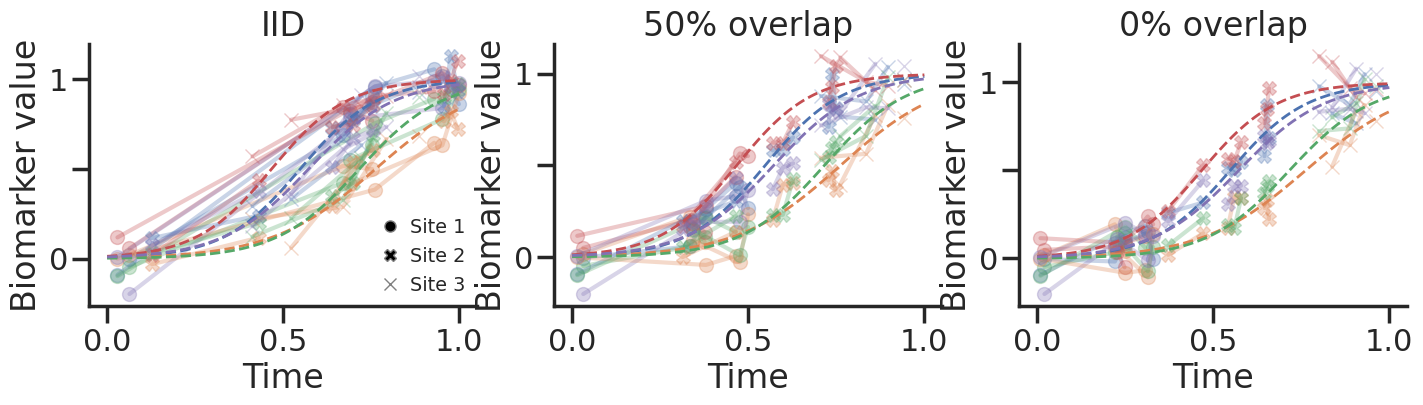

In [6]:
# # horizontal
# fig_data, axes = plt.subplots(
#     ncols=2, figsize={"paper": (6, 2.5), "talk": (8, 4)}[THEME]
# )

i_iteration = 14
titles_and_tags = {
    "IID": f"100percent_3sites_50subjects_{i_iteration}",
    "50% overlap": f"050percent_3sites_50subjects_{i_iteration}",
    "0% overlap": f"000percent_3sites_50subjects_{i_iteration}",
}

# vertical
fig_data, axes = plt.subplots(nrows=1, ncols=len(titles_and_tags), figsize=(17, 3.4))


for i_ax, ((title, tag), ax) in enumerate(zip(titles_and_tags.items(), axes)):
    ax: plt.Axes

    plot_simulated_data(tag, ax, with_legend=(i_ax == 0))
    ax.set_title(title)

# fig_data.tight_layout()

XLIM = axes[0].get_xlim()
YLIM = axes[0].get_ylim()

print(f"{XLIM=}")
print(f"{YLIM=}")

In [59]:
fig_data.savefig("simulation_data.svg", bbox_inches="tight", transparent=True)

## Synthetic data model fits

In [98]:
from typing import Optional

import seaborn as sns
import scipy

import json

import numpy as np
import pandas as pd
import torch
import scipy.stats
from sklearn.metrics import r2_score, mean_squared_error

from fl_prog.utils.io import DEFAULT_DPATH_DATA, DEFAULT_DPATH_RESULTS, get_dpath_latest

sns.set_theme(context="poster", style="ticks")


def check_model_fit(
    tag: str,
    setup: str,
    align_x=False,
    ax: Optional[plt.Axes] = None,
    **kwargs,
):

    TIME_LABEL = "Time"
    BIOMARKER_LABEL = "Biomarker value"

    # dname_data_date = DNAME_LATEST
    # dname_results_date = DNAME_LATEST

    dname_data_date = "2026_02_17"
    dname_results_date = "2026_02_17"

    data_dir = DEFAULT_DPATH_DATA / dname_data_date / tag
    results_dir = DEFAULT_DPATH_RESULTS / dname_results_date / tag

    fpath_json_data = data_dir / f"{tag}.json"
    json_data = json.loads(fpath_json_data.read_text())
    print(f"fpath_json_data: {str(fpath_json_data)}")

    try:
        fpath_json_results = results_dir / f"{tag}-estimated_params.json"
        results_dict = json.loads(fpath_json_results.read_text())
        print(f"fpath_json_results: {str(fpath_json_results)}")
    except FileNotFoundError:
        print("Results not available")

    n_biomarkers = json_data["settings"]["n_biomarkers"]

    params = json_data["params"]
    k_values = np.array(params["k_values"])
    x0_values = np.array(params["x0_values"])
    vertical_shifts = np.array(params.get("vertical_shifts", [0] * n_biomarkers))
    scaling_factors = np.array(params.get("scaling_factors", [1] * n_biomarkers))
    time_shifts = np.concatenate(params["time_shifts"])

    if ax is None:
        _, ax = plt.subplots()

    estimated_k_values = results_dict["results"][setup]["estimated_k_values"]
    estimated_x0_values = results_dict["results"][setup]["estimated_x0_values"]
    estimated_vertical_shifts = results_dict["results"][setup].get(
        "estimated_vertical_shifts", [0] * n_biomarkers
    )
    estimated_scaling_factors = results_dict["results"][setup].get(
        "estimated_scaling_factors", [1] * n_biomarkers
    )
    estimated_time_shifts = results_dict["results"][setup].get(
        "estimated_time_shifts", [0] * n_biomarkers
    )
    estimated_sigma = results_dict["results"][setup].get(
        "estimated_sigma", [0] * n_biomarkers
    )

    estimated_k_values = np.array(estimated_k_values)
    estimated_x0_values = np.array(estimated_x0_values)
    estimated_vertical_shifts = np.array(estimated_vertical_shifts)
    estimated_scaling_factors = np.array(estimated_scaling_factors)
    estimated_time_shifts = np.array(estimated_time_shifts)
    estimated_sigma = np.array(estimated_sigma)

    mean_x_value_difference = (x0_values - estimated_x0_values).mean()

    for i_biomarker, (k, x0, vertical_shift, scaling_factor) in enumerate(
        zip(k_values, x0_values, vertical_shifts, scaling_factors)
    ):

        # ground truth
        t = np.linspace(-1, 2, 100)
        y = 1 / (1 + np.exp(-k * (t - x0))) * scaling_factor + vertical_shift
        ax.plot(t, y, color=f"C{i_biomarker}", linestyle="--", alpha=0.8)

        if align_x:
            offset = mean_x_value_difference
        else:
            offset = 0.0

        # simulations
        y_pred = (
            1
            / (
                1
                + np.exp(
                    -estimated_k_values[i_biomarker]
                    * (t - offset - estimated_x0_values[i_biomarker])
                )
            )
            * estimated_scaling_factors[i_biomarker]
            + estimated_vertical_shifts[i_biomarker]
        )
        ax.plot(
            t,
            y_pred,
            color=f"C{i_biomarker}",
            linestyle="-",
            alpha=0.8,
        )

        ax.set_xlabel(TIME_LABEL)
        ax.set_ylabel(BIOMARKER_LABEL)

        try:
            ax.set_xlim(XLIM)
            ax.set_ylim(YLIM)
        except NameError:
            pass


def k_value_relative_error(
    k_values_true, k_values_estimated, x0_values_true, x0_values_estimated
):
    return np.mean(np.abs((k_values_estimated - k_values_true) / k_values_true))


def x0_value_rank_error(
    k_values_true, k_values_estimated, x0_values_true, x0_values_estimated
):
    k_c = scipy.stats.kendalltau(
        np.argsort(x0_values_true), np.argsort(x0_values_estimated)
    ).statistic
    n = len(x0_values_true)
    k_d = (1 - k_c) * (n * (n - 1)) / 4
    return k_d


def get_df_results(CONDITIONS, N_ITERATIONS, DPATH_DATA, DPATH_RESULTS):
    data_for_df = []
    missing_counts = {condition: 0 for condition in CONDITIONS}
    for condition in CONDITIONS:
        for i_iteration in range(1, N_ITERATIONS + 1):
            tag = f"{condition}_{i_iteration}"

            fpath_json_results = DPATH_RESULTS / tag / f"{tag}-estimated_params.json"
            if not fpath_json_results.exists():
                missing_counts[condition] += 1
                continue
            json_results = json.loads(fpath_json_results.read_text())
            results = json_results["results"]

            # load data
            fpath_json_data = DPATH_DATA / tag / f"{tag}.json"
            json_data = json.loads(fpath_json_data.read_text())
            cols = json_data["cols"]
            col_timepoint = cols["col_timepoint"]
            col_subject = cols["col_subject"]
            cols_biomarker = cols["cols_biomarker"]

            fpath_merged_data = DPATH_DATA / tag / f"{tag}-merged.tsv"
            df_merged = pd.read_csv(fpath_merged_data, sep="\t")

            # get original time points (before time shift)
            params = json_data["params"]
            x0_values = np.array(params["x0_values"])
            time_shifts = np.concatenate(params["time_shifts"])
            shifted_time = (
                df_merged[col_timepoint] + time_shifts[df_merged[col_subject]]
            )

            for i_biomarker, col_biomarker in enumerate(cols_biomarker):
                for setup in results.keys():
                    estimated_k_values = np.array(results[setup]["estimated_k_values"])
                    estimated_x0_values = np.array(
                        results[setup]["estimated_x0_values"]
                    )

                    mean_x_value_difference = (x0_values - estimated_x0_values).mean()

                    y_true = df_merged[col_biomarker].to_numpy()
                    y_pred = torch.sigmoid(
                        torch.tensor(
                            estimated_k_values[i_biomarker]
                            * (
                                shifted_time
                                - mean_x_value_difference
                                - estimated_x0_values[i_biomarker]
                            )
                        )
                    )

                    for metric, score_func in [
                        # ("r2_score", r2_score),
                        ("mean_squared_error", mean_squared_error),
                        # (
                        #     "correlation",
                        #     lambda y_true, y_pred: np.corrcoef(y_true, y_pred)[0, 1],
                        # ),
                    ]:
                        data_for_df.append(
                            {
                                "condition": condition,
                                "iteration": i_iteration,
                                "tag": tag,
                                "col_biomarker": col_biomarker,
                                "setup": setup.capitalize(),
                                "metric": metric,
                                "score": score_func(y_true, y_pred.numpy()),
                            }
                        )

                    for metric, score_func in [
                        ("k_value_relative_error", k_value_relative_error),
                        ("x0_value_rank_error", x0_value_rank_error),
                    ]:
                        data_for_df.append(
                            {
                                "condition": condition,
                                "iteration": i_iteration,
                                "tag": tag,
                                "col_biomarker": col_biomarker,
                                "setup": setup.capitalize(),
                                "metric": metric,
                                "score": score_func(
                                    params["k_values"],
                                    estimated_k_values,
                                    params["x0_values"],
                                    estimated_x0_values,
                                ),
                            }
                        )

    if sum(missing_counts.values()) == 0:
        print("All expected runs were found!")
    else:
        print("Missing runs:")
        for condition, count in missing_counts.items():
            if count > 0:
                print(f"  {condition}: {count}")

    return pd.DataFrame(data_for_df)


def plot_metrics(df_results, metric, ax, with_legend=False):

    LABEL_MAP = {
        "setup": "Setup",
        "federated": "Federated",
        "centralized": "Centralized",
        "r2_score": "R² score",
        "mean_squared_error": "Mean squared error",
        "correlation": "Correlation",
        "k_value_relative_error": "Percent error steepness",
        "x0_value_rank_error": "Kendall tau distance\nfor $m_j$ rank",
        "100percent_3sites_50subjects": "IID",
        "50percent_3sites_50subjects": "50% overlap",
        "0percent_3sites_50subjects": "0% overlap",
        "050percent_3sites_50subjects": "50% overlap",
        "000percent_3sites_50subjects": "0% overlap",
        "100percent_2sites_50subjects_20biomarkers": "IID",
        "050percent_2sites_50subjects_20biomarkers": "50% overlap",
        "000percent_2sites_50subjects_20biomarkers": "0% overlap",
        "100percent_5sites_50subjects_20biomarkers": "IID",
        "050percent_5sites_50subjects_20biomarkers": "50% overlap",
        "000percent_5sites_50subjects_20biomarkers": "0% overlap",
        "100percent_8sites_50subjects_20biomarkers": "IID",
        "050percent_8sites_50subjects_20biomarkers": "50% overlap",
        "000percent_8sites_50subjects_20biomarkers": "0% overlap",
    }
    LATEX_LABEL_MAP = {
        "r2_score": "$R^2$",
        "mean_squared_error": "MSE",
        "correlation": "Correlation",
        "k_value_relative_error": "Percent error steepness",
        "x0_value_rank_error": "Kendall tau distance",
        "100percent_3sites_50subjects": "IID",
        "050percent_3sites_50subjects": r"50\% overlap",
        "000percent_3sites_50subjects": r"0\% overlap",
    }
    METRIC_YLIM_MAP = {
        "r2_score": (None, 1.0),
        "mean_squared_error": (0.0, None),
        "correlation": (None, 1.0),
        "k_value_relative_error": (None, None),
        "x0_value_rank_error": (None, None),
    }

    # average over biomarker curves
    df_results_avg = (
        df_results.drop(columns="col_biomarker")
        .groupby(["metric", "condition", "setup", "iteration", "tag"])
        .mean()
        .reset_index()
    )

    sns.boxplot(
        data=df_results_avg.sort_values(
            by=["condition"],
            key=lambda s: pd.Series(
                [
                    {
                        "IID": 0,
                        "50% overlap": 1,
                        "0% overlap": 2,
                    }[LABEL_MAP[x]]
                    for x in s
                ]
            ),
        ).query("metric == @metric"),
        x="condition",
        y="score",
        hue="setup",
        hue_order=["Centralized", "Federated"],
        showfliers=False,
        ax=ax,
        legend=with_legend,
        linewidth=2,
    )

    if with_legend:
        legend = ax.legend(
            fontsize="x-small",
            frameon=False,
            loc="upper left",
            borderpad=0.2,
            handlelength=1.5,
            handletextpad=0.4,
            labelspacing=0.25,
        )
        legend.set_title("")
        for handle in legend.legendHandles:
            handle.set_linewidth(2)

    ax.set_title(LABEL_MAP[metric])
    ax.set_ylabel("")
    xticklabels = [
        LABEL_MAP.get(label.get_text(), label.get_text()).replace(" ", "\n")
        for label in ax.get_xticklabels()
    ]
    if len(xticklabels) > 0:
        ax.set_xticks(
            ax.get_xticks(),
            labels=xticklabels,
            # rotation=20,
            # ha="right",
            # rotation_mode="anchor",
        )
    ax.set_xlabel("")
    ax.set_ylim(METRIC_YLIM_MAP[metric])

All expected runs were found!
fpath_json_data: /data/origami/michelle/projects/fl-prog/data/2026_02_17/100percent_3sites_50subjects_14/100percent_3sites_50subjects_14.json
fpath_json_results: /data/origami/michelle/projects/fl-prog/results/2026_02_17/100percent_3sites_50subjects_14/100percent_3sites_50subjects_14-estimated_params.json
fpath_json_data: /data/origami/michelle/projects/fl-prog/data/2026_02_17/100percent_3sites_50subjects_14/100percent_3sites_50subjects_14.json
fpath_json_results: /data/origami/michelle/projects/fl-prog/results/2026_02_17/100percent_3sites_50subjects_14/100percent_3sites_50subjects_14-estimated_params.json
fpath_json_data: /data/origami/michelle/projects/fl-prog/data/2026_02_17/050percent_3sites_50subjects_14/050percent_3sites_50subjects_14.json
fpath_json_results: /data/origami/michelle/projects/fl-prog/results/2026_02_17/050percent_3sites_50subjects_14/050percent_3sites_50subjects_14-estimated_params.json
fpath_json_data: /data/origami/michelle/projects/

/tmp/ipykernel_4047201/498093239.py:341: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


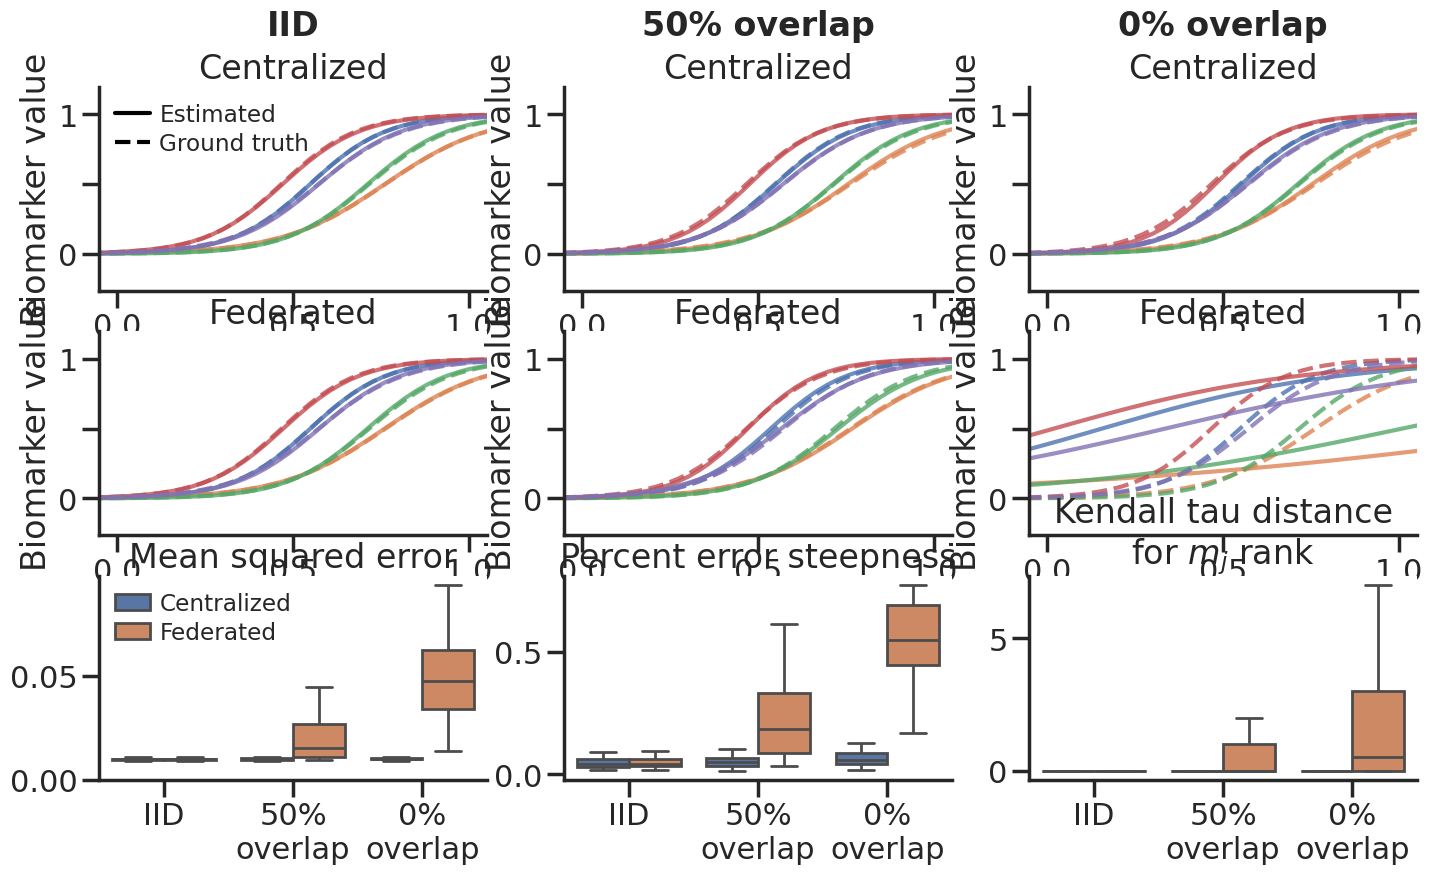

In [108]:
import matplotlib.pyplot as plt

XLIM = (-0.05, 1.05)
YLIM = (-0.26390034400000445, 1.1959118913944633)

tags_and_titles = {
    v: k
    for k, v in {
        "IID": f"100percent_3sites_50subjects_{i_iteration}",
        "50% overlap": f"050percent_3sites_50subjects_{i_iteration}",
        "0% overlap": f"000percent_3sites_50subjects_{i_iteration}",
    }.items()
}

CONDITIONS = [
    "100percent_3sites_50subjects",
    "050percent_3sites_50subjects",
    "000percent_3sites_50subjects",
]
N_ITERATIONS = 50
DPATH_DATA = DEFAULT_DPATH_DATA / "2026_02_17"
DPATH_RESULTS = DEFAULT_DPATH_RESULTS / "2026_02_17"

# vertical
fig_model_fit, axes = plt.subplots(nrows=3, ncols=3, figsize=(17, 9), squeeze=False)

df_results = get_df_results(CONDITIONS, N_ITERATIONS, DPATH_DATA, DPATH_RESULTS)
for i_col, metric in enumerate(
    [
        "mean_squared_error",
        "k_value_relative_error",
        "x0_value_rank_error",
    ]
):
    ax = axes[2, i_col]
    plot_metrics(df_results, metric=metric, ax=ax, with_legend=(i_col == 0))

    ax.spines[["top", "right"]].set_visible(False)
    # ax.set_title(LATEX_LABEL_MAP[metric])

for i_col, (title, tag) in enumerate(titles_and_tags.items()):
    for i_row, setup in enumerate(["centralized", "federated"]):
        ax = axes[i_row, i_col]
        check_model_fit(
            tag=tag,
            setup=setup,
            align_x=True,
            ax=ax,
        )
        ax.set_title(setup.capitalize())
        ax.set_xlim(XLIM)
        ax.set_ylim(YLIM)
        ax.set_yticks([0, 0.5, 1], ["0", "", "1"])
        ax.spines[["top", "right"]].set_visible(False)
        # if i_row == 0:
        #     ax.set_xticks([0, 0.5, 1], labels=["", "", ""])
        #     ax.set_xlabel("")

        if i_col == 0 and i_row == 0:
            handles = [
                plt.Line2D(
                    [0],
                    [0],
                    color="black",
                    linestyle="-",
                    label="Estimated",
                ),
                plt.Line2D(
                    [0],
                    [0],
                    color="black",
                    linestyle="--",
                    label="Ground truth",
                ),
            ]
            legend = ax.legend(
                handles=handles,
                fontsize="x-small",
                frameon=False,
                loc="upper left",
                borderpad=0.2,
                handletextpad=0.4,
                handlelength=1.5,
                labelspacing=0.25,
            )

        ax.spines[["top", "right"]].set_visible(False)

        if i_row == 0:
            ax.annotate(
                tags_and_titles[tag],
                xy=(0.5, 1.3),
                xycoords="axes fraction",
                ha="center",
                va="center",
                # fontsize="medium",
                fontweight="bold",
            )


# fig_model_fit.tight_layout()

In [109]:
fig_model_fit.savefig("simulated_model_fit.svg", bbox_inches="tight", transparent=True)

## ADNI demographics

In [7]:
import pandas as pd

merge_hemispheres = True

col_subject = "rid"
col_visit = "visit"
col_months = "months_str"
col_months_float = "months"
dataset_specific_cols = [col_subject, col_visit]

cols_to_drop = ["Age", "Sex", "MMSE", "DX"]

df_adni = pd.read_csv(
    "/home/nikhil/projects/fed_learning/fl-prog/data/_Marco_data/raw/ADNI_freesurfer7p1p1-forSantiago.csv",
    # index_col=dataset_specific_cols,
    dtype={col: str for col in dataset_specific_cols},
)

if merge_hemispheres:
    from fl_prog.freesurfer import _merge_hemispheres

    df_adni = _merge_hemispheres(df_adni)

# df_adni = df_adni.reset_index()
df_adni[col_months] = df_adni[col_visit].map(lambda x: int(x.removeprefix("M")))
df_adni = df_adni.query(f"{col_months} < 108")
months = df_adni[col_months].sort_values().unique().astype(str)
df_adni[col_months_float] = df_adni[col_months]
df_adni[col_months] = df_adni[col_months].astype(str)
print(f"{df_adni[col_subject].nunique()} unique subjects")

df_adni = df_adni.drop(columns=cols_to_drop)

df_adni = df_adni.set_index([col_subject, col_visit, col_months, col_months_float])

df_adni

2196 unique subjects


Left-Lateral-Ventricle  Left-Inf-Lat-Vent  \
rid  visit months_str months                                              
295  M00   0          0                      23466.8             1023.5   
     M06   6          6                      23415.1             1038.8   
     M12   12         12                     23943.3             1084.7   
     M24   24         24                     25269.1              930.9   
     M36   36         36                     26235.7             1110.5   
...                                              ...                ...   
6575 M12   12         12                     31860.1             1223.3   
6580 M00   0          0                      28071.2             1555.3   
     M12   12         12                     28876.8             1601.9   
6581 M00   0          0                      37084.3              555.4   
6803 M00   0          0                      23516.0             2793.9   

                              Left-Cerebellum-White-Matter  \
rid  visit months_str months                                 
295  M00   0          0                            14389.3   
     M06   6          6                            14681.8   
     M12   12         12                           14099.2   
     M24   24         24                           13488.2   
     M36   36         36                           14464.9   
...                                                    ...   
6575 M12   12         12                           16274.7   
6580 M00   0          0                            13111.8   
     M12   12         12                           13099.1   
6581 M00   0          0                            19731.4   
6803 M00   0          0                            14427.7   

                              Left-Cerebellum-Cortex  Left-Thalamus  \
rid  visit months_str months                                          
295  M00   0          0                      58007.3         7053.7   
     M06   6          6                      56396.6         7278.7   
     M12   12         12                     56226.6         7346.7   
     M24   24         24                     54604.0         7016.2   
     M36   36         36                     57098.1         7152.9   
...                                              ...            ...   
6575 M12   12         12                     58225.7         7857.2   
6580 M00   0          0                      49636.1         5736.4   
     M12   12         12                     50882.7         5615.8   
6581 M00   0          0                      54175.9         7462.7   
6803 M00   0          0                      49745.2         6185.5   

                              Left-Caudate  Left-Putamen  Left-Pallidum  \
rid  visit months_str months                                              
295  M00   0          0             3283.4        4520.3         2012.8   
     M06   6          6             3355.3        4601.5         1953.2   
     M12   12         12            3321.2        4733.9         2222.9   
     M24   24         24            3352.3        4462.5         2072.3   
     M36   36         36            3089.2        4416.8         2150.2   
...                                    ...           ...            ...   
6575 M12   12         12            3916.1        4442.7         2139.1   
6580 M00   0          0             3084.0        3615.5         1827.9   
     M12   12         12            3119.8        3586.9         1874.3   
6581 M00   0          0             3463.2        4528.7         1989.0   
6803 M00   0          0             2800.0        4398.8         1943.5   

                              X3rd-Ventricle  X4th-Ventricle  ...  \
rid  visit months_str months                                  ...   
295  M00   0          0               2071.2          1661.6  ...   
     M06   6          6               2047.5          1619.0  ...   
     M12   12         12              2005.7          1811.2  ...   
  

In [8]:
df_adni.index.get_level_values("rid").nunique()

2196

In [9]:
df_demographics = pd.read_csv(
    "/home/nikhil/projects/fed_learning/fl-prog/data/ADNIMERGE.csv",
    low_memory=False,
    dtype={"RID": str, "Month": str},
)
df_demographics = df_demographics.query('RID in @df_adni.index.get_level_values("rid")')
df_demographics_baseline = df_demographics.query('VISCODE == "bl"')
df_demographics_baseline = df_demographics_baseline.loc[
    df_demographics_baseline["AGE"].notnull()
]
df_demographics_baseline

,RID,COLPROT,ORIGPROT,PTID,SITE,VISCODE,EXAMDATE,DX_bl,AGE,PTGENDER,...,PTAU_bl,FDG_bl,PIB_bl,AV45_bl,FBB_bl,Years_bl,Month_bl,Month,M,update_stamp
0,2,ADNI1,ADNI1,011_S_0002,11,bl,2005-09-08,CN,74.3,Male,...,NaN,1.25173,NaN,NaN,NaN,0.0,0.0,0,0,2022-06-22 16:41:44.0
1,3,ADNI1,ADNI1,011_S_0003,11,bl,2005-09-12,AD,81.3,Male,...,22.83,1.22163,NaN,NaN,NaN,0.0,0.0,0,0,2022-06-22 16:41:44.0
5,4,ADNI1,ADNI1,022_S_0004,22,bl,2005-11-08,LMCI,67.5,Male,...,13.29,NaN,NaN,NaN,NaN,0.0,0.0,0,0,2022-06-22 16:41:44.0
10,5,ADNI1,ADNI1,011_S_0005,11,bl,2005-09-07,CN,73.7,Male,...,33.43,1.28391,NaN,NaN,NaN,0.0,0.0,0,0,2022-06-22 16:41:44.0
15,6,ADNI1,ADNI1,100_S_0006,100,bl,2005-11-29,LMCI,80.4,Female,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0,2022-06-22 16:41:44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15559,6846,ADNI3,ADNI3,024_S_6846,24,bl,2020-01-23,EMCI,77.1,Male,...,NaN,1.23532,NaN,NaN,1.5671,0.0,0.0,0,0,2022-06-22 16:42:00.0
15561,6850,ADNI3,ADNI3,305_S_6850,305,bl,2020-02-13,AD,79.7,Male,...,NaN,1.13333,NaN,0.8548,NaN,0.0,0.0,0,0,2022-06-22 16:42:00.0
15563,6852,ADNI3,ADNI3,129_S_6852,129,bl,2020-02-19,EMCI,76.4,Male,...,NaN,1.22968,NaN,1.5553,NaN,0.0,0.0,0,0,2022-06-22 16:42:00.0
15565,6857,ADNI3,ADNI3,129_S_6857,129,bl,2020-03-09,LMCI,71.4,Male,...,NaN,NaN,NaN,1.0243,NaN,0.0,0.0,0,0,2022-06-22 16:42:00.0


In [42]:
df_demographics["VISCODE"].unique()

array(['bl', 'm06', 'm12', 'm24', 'm18', 'm36', 'm48', 'm60', 'm03',
       'm30', 'm84', 'm42', 'm72', 'm54', 'm66', 'm78', 'm108', 'm96',
       'm90', 'm120', 'm114', 'm102', 'm126', 'm132', 'm144', 'm156',
       'm168', 'm180', 'm162', 'm174', 'm186', 'm138', 'm150', 'm0',
       'm192'], dtype=object)

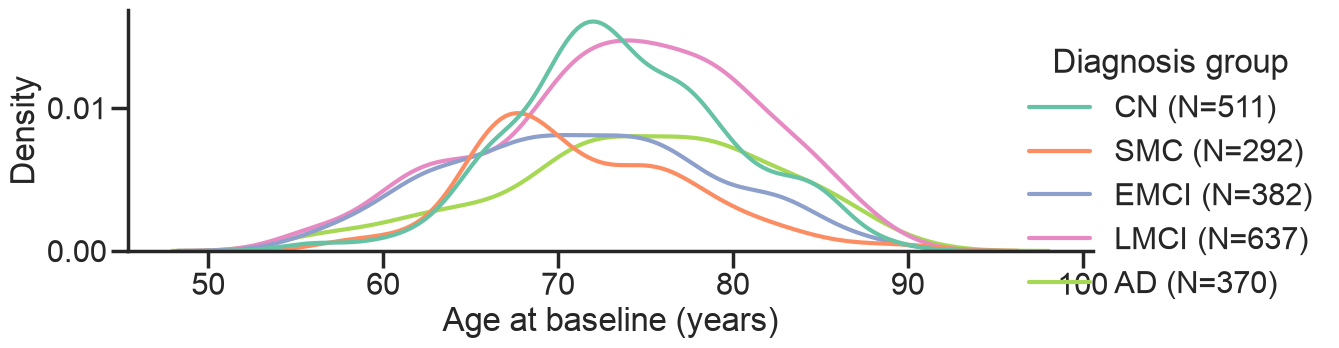

In [10]:
import seaborn as sns

sns.set_theme(context="poster", style="ticks")

group_counts = df_demographics_baseline.groupby("DX_bl").size().to_dict()

fig_age = sns.displot(
    data=df_demographics_baseline,
    x="AGE",
    hue="DX_bl",
    kind="kde",
    hue_order=["CN", "SMC", "EMCI", "LMCI", "AD"],
    height=4,
    aspect=3,
    palette="Set2",
)

fig_age.legend.set_title("Diagnosis group")
fig_age.ax.set_xlabel("Age at baseline (years)")

for text in fig_age.legend.texts:
    group = text.get_text()
    new_label = f"{group} (N={group_counts[group]})"
    text.set_text(new_label)

In [11]:
fig_age.savefig("adni_age_groups.svg", bbox_inches="tight", transparent=True)

## Model fits and time shifts

In [12]:
import json
from pathlib import Path

from fl_prog.utils.constants import NODE_PREFIX
import pandas as pd

import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="poster", style="ticks")


def get_time_shift_by_subject(
    estimated_time_shifts, subjects_by_node, time_scaling_factor=1.0
):

    dfs_time_shifts = []
    for node_id, time_shifts in estimated_time_shifts.items():
        df_time_shifts = pd.DataFrame(
            {
                "participant_id": [
                    str(subject)
                    for subject in subjects_by_node[node_id.removeprefix(NODE_PREFIX)]
                ],
                # "participant_id": subjects_by_node[node_id.removeprefix(NODE_PREFIX)],
                "estimated_time_shift": time_shifts,
            }
        )
        df_time_shifts["estimated_time_shift"] = (
            df_time_shifts["estimated_time_shift"].astype(float) * time_scaling_factor
        )
        dfs_time_shifts.append(df_time_shifts)

    time_shift_by_subject = (
        pd.concat(dfs_time_shifts, ignore_index=True)
        .set_index("participant_id")
        .squeeze()
        .to_dict()
    )
    return time_shift_by_subject


def plot_model_fit(ax, tag, legend=False):

    dname_date = "2026_06_02"
    fpath_json = Path(f"../results/{dname_date}/{tag}/{tag}-estimated_params.json")
    json_content = json.loads(fpath_json.read_text())
    cols_biomarker = json_content["settings"]["config"]["cols"]["cols_biomarker"]

    time_scaling_factor = json_content["settings"]["config"]["settings"]["config"][
        "max_time"
    ]
    min_max_by_measure = json_content["settings"]["config"]["settings"]["config"][
        "min_max_by_measure"
    ]
    results = json_content["results"]

    data_fitted_models = []

    for setup in results:
        for biomarker, k, x0, vertical_shift, scaling_factor in zip(
            cols_biomarker,
            results[setup]["estimated_k_values"],
            results[setup]["estimated_x0_values"],
            results[setup]["estimated_vertical_shifts"],
            results[setup]["estimated_scaling_factors"],
        ):
            months = np.linspace(-0.5, 4, 100)
            values = scaling_factor * (
                1 / (1 + np.exp(-k * (months - x0))) + vertical_shift
            )

            biomarker_min, biomarker_max = min_max_by_measure[biomarker]

            data_fitted_models.extend(
                [
                    {
                        "setup": setup,
                        "biomarker": biomarker,
                        "x": month * time_scaling_factor,
                        "y": value,
                        "y_transformed": (
                            value * (biomarker_max - biomarker_min) + biomarker_min
                        ),
                    }
                    for month, value in zip(months, values)
                ]
            )

    df_fitted_models = pd.DataFrame(data_fitted_models)

    sns.lineplot(
        data=df_fitted_models,
        x="x",
        y="y",
        # y="y_transformed",
        hue="biomarker",
        style="setup",
        # kind="line",
        ax=ax,
        legend=legend,
        linewidth=2,
    )

    ax.set_ylabel("Biomarker value")
    ax.set_xlabel("Months")
    ax.set_yticks([0, 0.5, 1], labels=["0", "", "1"])

    if legend:
        sns.move_legend(
            ax,
            "upper left",
            fontsize="xx-small",
            handlelength=1,
            labelspacing=0.2,
            handletextpad=0.4,
        )


def plot_time_shifts(tag, ax):
    dname_date = "2026_06_02"
    fpath_json = Path(f"../results/{dname_date}/{tag}/{tag}-estimated_params.json")
    print(fpath_json)
    json_content = json.loads(fpath_json.read_text())

    subjects_by_node = json_content["settings"]["config"]["subjects_by_node"]
    time_scaling_factor = json_content["settings"]["config"]["settings"]["config"][
        "max_time"
    ]
    results = json_content["results"]

    time_shift_by_subject = get_time_shift_by_subject(
        results["federated"]["estimated_time_shifts"],
        subjects_by_node,
        time_scaling_factor=time_scaling_factor,
    )

    import numpy as np

    hue_order = ["CN", "SMC", "EMCI", "LMCI", "AD"]

    df_time_shifts = pd.DataFrame(
        time_shift_by_subject.items(),
        columns=["participant_id", "estimated_time_shift"],
    )

    df_time_shifts["group"] = df_time_shifts["participant_id"].map(
        df_demographics_baseline.set_index("RID")["DX_bl"].to_dict()
    )

    sns.boxplot(
        data=df_time_shifts.sort_values(
            "group",
            key=lambda x: x.map({group: i for i, group in enumerate(hue_order)}),
        ),
        y="estimated_time_shift",
        x="group",
        hue="group",
        hue_order=hue_order,
        ax=ax,
        palette="Set2",
    )

    ax.set_xlabel("Diagnosis group")
    ax.set_title("Est. time shift (months)")
    ax.set_ylabel("")

../results/2026_06_02/adni_iid/adni_iid-estimated_params.json
(np.float64(-69.6), np.float64(405.6))
(np.float64(-69.6), np.float64(405.6))


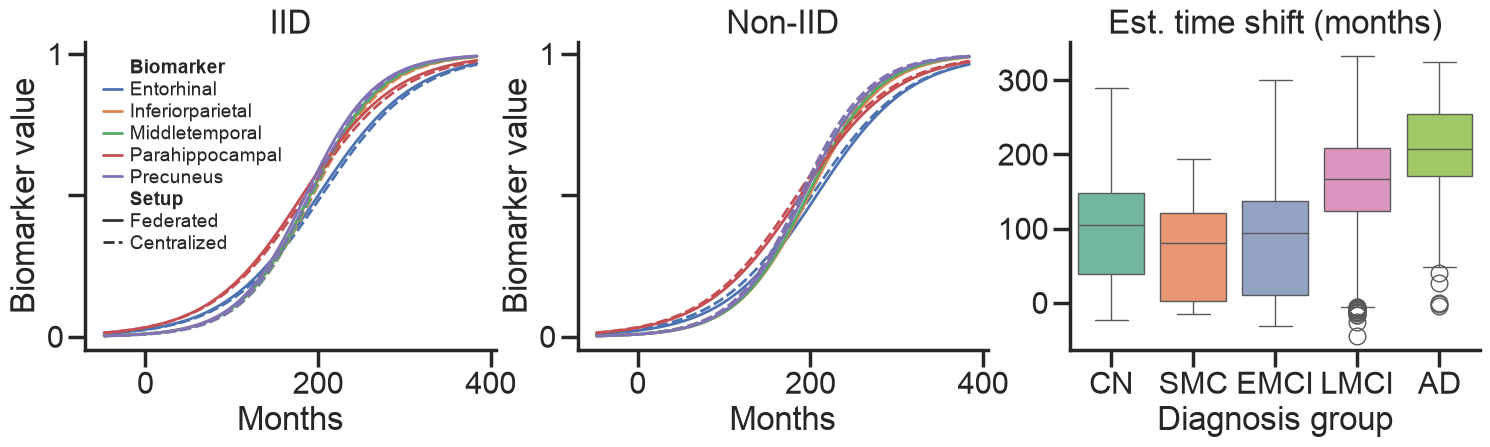

In [14]:
import matplotlib.pyplot as plt
import matplotlib
import json
from pathlib import Path

tag = "adni_noniid"
dname_date = "2026_06_02"
fpath_json = Path(f"../results/{dname_date}/{tag}/{tag}-estimated_params.json")
json_content = json.loads(fpath_json.read_text())
cols_biomarker = json_content["settings"]["config"]["cols"]["cols_biomarker"]
n_biomarkers = len(cols_biomarker)

time_scaling_factor = json_content["settings"]["config"]["settings"]["config"]["max_time"]
min_max_by_measure = json_content["settings"]["config"]["settings"]["config"]["min_max_by_measure"]
results = json_content["results"]

# Create subplots - one per biomarker
fig, axes = plt.subplots(nrows=1, ncols=n_biomarkers, figsize=(5*n_biomarkers, 4))
if n_biomarkers == 1:
    axes = [axes]

# Plot each biomarker in a separate panel with both setups
for ax_idx, biomarker in enumerate(cols_biomarker):
    ax = axes[ax_idx]
    
    # Plot both setups for this biomarker
    for setup in results:
        for i_biomarker, col_biomarker in enumerate(cols_biomarker):
            if col_biomarker != biomarker:
                continue
            
            k = results[setup]["estimated_k_values"][i_biomarker]
            x0 = results[setup]["estimated_x0_values"][i_biomarker]
            vertical_shift = results[setup]["estimated_vertical_shifts"][i_biomarker]
            scaling_factor = results[setup]["estimated_scaling_factors"][i_biomarker]
            
            months = np.linspace(-0.5, 4, 100)
            values = scaling_factor * (1 / (1 + np.exp(-k * (months - x0))) + vertical_shift)
            
            ax.plot(
                months * time_scaling_factor,
                values,
                label=setup.capitalize(),
                linewidth=2,
                linestyle="-" if setup == "federated" else "--"
            )
    
    ax.set_title(biomarker, fontweight="bold")
    ax.set_ylabel("Biomarker value" if ax_idx == 0 else "")
    ax.set_xlabel("Months")
    ax.set_yticks([0, 0.5, 1], labels=["0", "", "1"])
    ax.spines[["top", "right"]].set_visible(False)
    
    # Add legend to first panel only
    if ax_idx == 0:
        ax.legend(fontsize="x-small", handlelength=1.5, frameon=False, loc="upper left")

fig.tight_layout()


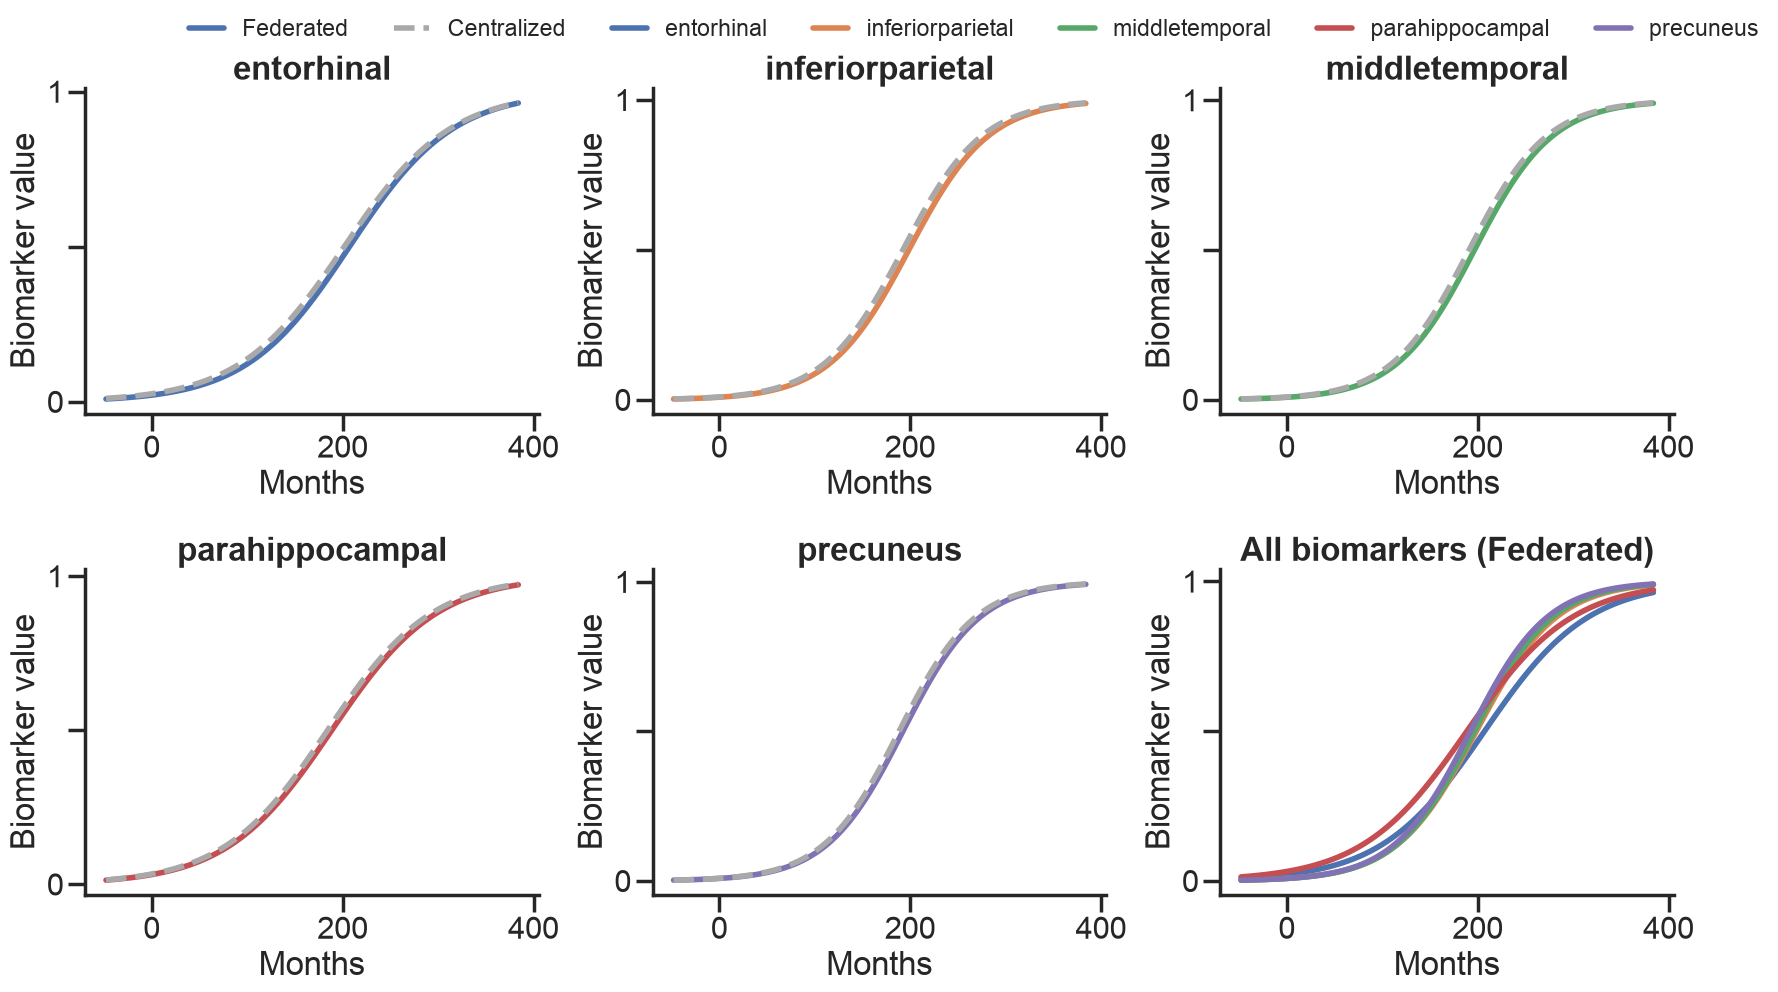

In [33]:
import matplotlib.pyplot as plt
import matplotlib
import json
from pathlib import Path

tag = "adni_noniid"
dname_date = "2026_06_02"
fpath_json = Path(f"../results/{dname_date}/{tag}/{tag}-estimated_params.json")
json_content = json.loads(fpath_json.read_text())
cols_biomarker = json_content["settings"]["config"]["cols"]["cols_biomarker"]
n_biomarkers = len(cols_biomarker)

time_scaling_factor = json_content["settings"]["config"]["settings"]["config"]["max_time"]
min_max_by_measure = json_content["settings"]["config"]["settings"]["config"]["min_max_by_measure"]
results = json_content["results"]

# Create 2x3 grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

# Get colors for each biomarker
colors = [f"C{i}" for i in range(n_biomarkers)]

# Collect handles and labels for figure-level legend
legend_handles = []
legend_labels = []

# First 5 subplots: each biomarker with both setups (Federated vs Centralized)
for ax_idx, biomarker in enumerate(cols_biomarker[:5]):
    ax = axes[ax_idx]
    
    # Plot both setups for this biomarker
    for setup in results:
        for i_biomarker, col_biomarker in enumerate(cols_biomarker):
            if col_biomarker != biomarker:
                continue
            
            k = results[setup]["estimated_k_values"][i_biomarker]
            x0 = results[setup]["estimated_x0_values"][i_biomarker]
            vertical_shift = results[setup]["estimated_vertical_shifts"][i_biomarker]
            scaling_factor = results[setup]["estimated_scaling_factors"][i_biomarker]
            
            months = np.linspace(-0.5, 4, 100)
            values = scaling_factor * (1 / (1 + np.exp(-k * (months - x0))) + vertical_shift)
            
            # Use color for federated, dark gray for centralized
            plot_color = colors[i_biomarker] if setup == "federated" else "darkgray"
            
            line = ax.plot(
                months * time_scaling_factor,
                values,
                label=setup.capitalize(),
                linewidth=4,
                linestyle="-" if setup == "federated" else "--",
                color=plot_color
            )
            
            # Collect handles and labels only once for each setup
            if ax_idx == 0 and setup != "centralized" or ax_idx == 0 and setup == "centralized":
                if setup.capitalize() not in legend_labels:
                    legend_handles.append(line[0])
                    legend_labels.append(setup.capitalize())
    
    ax.set_title(biomarker.replace("_thickness", ""), fontweight="bold")
    ax.set_ylabel("Biomarker value")
    ax.set_xlabel("Months")
    ax.set_yticks([0, 0.5, 1], labels=["0", "", "1"])
    ax.spines[["top", "right"]].set_visible(False)

# Last subplot: all biomarkers in Federated setup
ax = axes[5]
for i_biomarker, col_biomarker in enumerate(cols_biomarker):
    k = results["federated"]["estimated_k_values"][i_biomarker]
    x0 = results["federated"]["estimated_x0_values"][i_biomarker]
    vertical_shift = results["federated"]["estimated_vertical_shifts"][i_biomarker]
    scaling_factor = results["federated"]["estimated_scaling_factors"][i_biomarker]
    
    months = np.linspace(-0.5, 4, 100)
    values = scaling_factor * (1 / (1 + np.exp(-k * (months - x0))) + vertical_shift)
    
    line = ax.plot(
        months * time_scaling_factor,
        values,
        label=col_biomarker.replace("_thickness", ""),
        linewidth=4,
        color=colors[i_biomarker]
    )
    
    legend_handles.append(line[0])
    legend_labels.append(col_biomarker.replace("_thickness", ""))

ax.set_title("All biomarkers (Federated)", fontweight="bold")
ax.set_ylabel("Biomarker value")
ax.set_xlabel("Months")
ax.set_yticks([0, 0.5, 1], labels=["0", "", "1"])
ax.spines[["top", "right"]].set_visible(False)

# Create single legend at the top of the entire figure
fig.legend(legend_handles, legend_labels, loc="upper center", ncol=7, 
           bbox_to_anchor=(0.5, 1.02), fontsize="x-small", handlelength=1.5, frameon=False)

fig.tight_layout()
fig.subplots_adjust(right=0.85, top=0.93)


In [73]:
adas_cols = [c for c in df_demographics.columns if "ADAS" in c.upper()]
print("ADAS-related columns:", adas_cols)


ADAS-related columns: ['ADAS11', 'ADAS13', 'ADASQ4', 'ADAS11_bl', 'ADAS13_bl', 'ADASQ4_bl']


In [74]:
# Create comprehensive dataframe for timeshift analysis subjects
# with baseline demographics and MMSE / ADAS scores at baseline and last visit

# Get all participant IDs from timeshift analysis (from previous cell)
all_participant_ids = list(participant_ids_in_analysis)

# Create base dataframe
df_subjects = pd.DataFrame({
    "participant_id": all_participant_ids
})

# Add data from demographics_baseline
bl_lookup = df_demographics_baseline.set_index("RID")
for col in ["AGE", "DX_bl", "MMSE", "ADAS11", "ADAS13", "ADASQ4"]:
    dest = {"AGE": "age", "DX_bl": "diagnosis_group"}.get(col, col + "_baseline")
    df_subjects[dest] = df_subjects["participant_id"].map(bl_lookup[col].to_dict())

# Helper: get score at last visit for each participant
def viscode_to_months(viscode):
    v = str(viscode).strip().lower()
    if v == "bl":
        return 0.0
    if v.startswith("m"):
        try:
            return float(v[1:])
        except ValueError:
            return np.nan
    return np.nan

df_demo_lv = df_demographics[df_demographics["RID"].isin(all_participant_ids)].copy()
df_demo_lv["VISCODE_num"] = df_demo_lv["VISCODE"].apply(viscode_to_months)
df_demo_lv = df_demo_lv.dropna(subset=["VISCODE_num"])

for col in ["MMSE", "ADAS11", "ADAS13", "ADASQ4"]:
    df_valid = df_demo_lv.dropna(subset=[col])
    idx_last = df_valid.groupby("RID")["VISCODE_num"].idxmax()
    last_val = (
        df_valid.loc[idx_last, ["RID", col]]
        .rename(columns={"RID": "participant_id", col: f"{col}_last_visit"})
    )
    df_subjects = df_subjects.merge(last_val, on="participant_id", how="left")

# Display summary
print(f"Total subjects: {len(df_subjects)}")
print(f"\nColumns: {df_subjects.columns.tolist()}")
print(f"\nMissing values:\n{df_subjects.isnull().sum()}")
display(df_subjects.head(5))


Total subjects: 2192

Columns: ['participant_id', 'age', 'diagnosis_group', 'MMSE_baseline', 'ADAS11_baseline', 'ADAS13_baseline', 'ADASQ4_baseline', 'MMSE_last_visit', 'ADAS11_last_visit', 'ADAS13_last_visit', 'ADASQ4_last_visit']

Missing values:
participant_id        0
age                   0
diagnosis_group       0
MMSE_baseline         0
ADAS11_baseline       4
ADAS13_baseline      15
ADASQ4_baseline       0
MMSE_last_visit       0
ADAS11_last_visit     0
ADAS13_last_visit     0
ADASQ4_last_visit     0
dtype: int64


,participant_id,age,diagnosis_group,MMSE_baseline,ADAS11_baseline,ADAS13_baseline,ADASQ4_baseline,MMSE_last_visit,ADAS11_last_visit,ADAS13_last_visit,ADASQ4_last_visit
0,4732,77.2,AD,21.0,21.00,32.00,10.0,18.0,19.00,31.00,10.0
1,231,60.3,LMCI,29.0,8.33,17.33,9.0,27.0,10.33,22.33,9.0
2,6441,88.6,LMCI,27.0,8.67,12.67,4.0,28.0,8.67,12.67,3.0
3,2233,55.5,EMCI,30.0,2.00,3.00,1.0,30.0,1.33,4.33,1.0
4,1080,81.4,LMCI,28.0,12.00,18.00,5.0,16.0,21.00,35.00,9.0


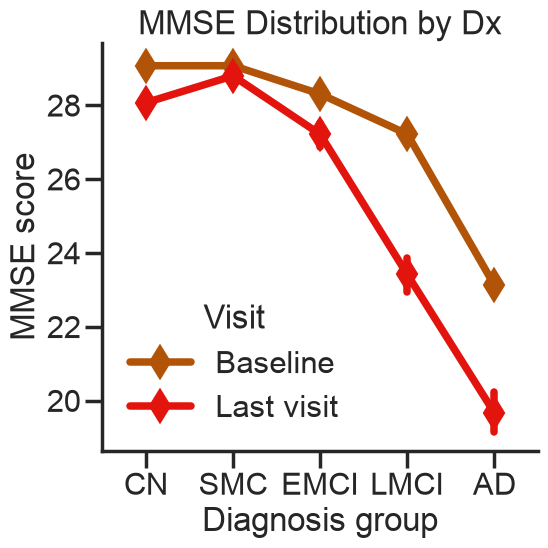

In [58]:
# Plot MMSE distribution at baseline and last visit stratified by diagnosis group
# Using the same subjects from the time shift analysis

tag = "adni_noniid"
dname_date = "2026_06_02"
fpath_json = Path(f"../results/{dname_date}/{tag}/{tag}-estimated_params.json")
json_content = json.loads(fpath_json.read_text())

subjects_by_node = json_content["settings"]["config"]["subjects_by_node"]
time_scaling_factor = json_content["settings"]["config"]["settings"]["config"]["max_time"]
results = json_content["results"]

time_shift_by_subject = get_time_shift_by_subject(
    results["federated"]["estimated_time_shifts"],
    subjects_by_node,
    time_scaling_factor=time_scaling_factor,
)

# Get participant IDs used in time shift analysis
participant_ids_in_analysis = set(time_shift_by_subject.keys())

# Build dataframe with baseline and last-visit MMSE for selected participants
df_mmse = pd.DataFrame({"participant_id": list(participant_ids_in_analysis)})

df_mmse["group"] = df_mmse["participant_id"].map(
    df_demographics_baseline.set_index("RID")["DX_bl"].to_dict()
)
df_mmse["MMSE_baseline"] = df_mmse["participant_id"].map(
    df_demographics_baseline.set_index("RID")["MMSE"].to_dict()
)

# Last-visit MMSE: latest VISCODE month per participant in demographics table
df_demo_subset = df_demographics[df_demographics["RID"].isin(participant_ids_in_analysis)].copy()
df_demo_subset = df_demo_subset.dropna(subset=["MMSE", "VISCODE"])

def viscode_to_months(viscode):
    viscode = str(viscode).strip().lower()
    if viscode == "bl":
        return 0.0
    if viscode.startswith("m"):
        try:
            return float(viscode[1:])
        except ValueError:
            return np.nan
    return np.nan

df_demo_subset["VISCODE_num"] = df_demo_subset["VISCODE"].apply(viscode_to_months)
df_demo_subset = df_demo_subset.dropna(subset=["VISCODE_num"])

idx_last = df_demo_subset.groupby("RID")["VISCODE_num"].idxmax()
df_last_mmse = (
    df_demo_subset.loc[idx_last, ["RID", "MMSE"]]
    .rename(columns={"RID": "participant_id", "MMSE": "MMSE_last_visit"})
)

df_mmse = df_mmse.merge(df_last_mmse, on="participant_id", how="left")

# Long format for plotting baseline vs last visit together
df_mmse_long = df_mmse.melt(
    id_vars=["participant_id", "group"],
    value_vars=["MMSE_baseline", "MMSE_last_visit"],
    var_name="visit_type",
    value_name="MMSE",
)
df_mmse_long = df_mmse_long.dropna(subset=["MMSE", "group"])
df_mmse_long["visit_type"] = df_mmse_long["visit_type"].map(
    {"MMSE_baseline": "Baseline", "MMSE_last_visit": "Last visit"}
)

hue_order = ["CN", "SMC", "EMCI", "LMCI", "AD"]

fig, ax = plt.subplots(figsize=(6, 6))

sns.pointplot(
    data=df_mmse_long,
    x="group",
    y="MMSE",
    hue="visit_type",
    order=hue_order,
    marker="d",
    hue_order=["Baseline", "Last visit"],
    ax=ax,
    palette={"Baseline": "#B15408", "Last visit": "#E2140D"},
)

ax.set_xlabel("Diagnosis group")
ax.set_ylabel("MMSE score")
ax.set_title("MMSE Distribution by Dx")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Visit", frameon=False)

fig.tight_layout()


Excluded 17 participants with MMSE_last_visit < 5.
                   n  pearson_r
diagnosis_group                
CN               511  -0.247894
SMC              292  -0.156637
EMCI             381  -0.356743
LMCI             631  -0.415734
AD               360  -0.406649


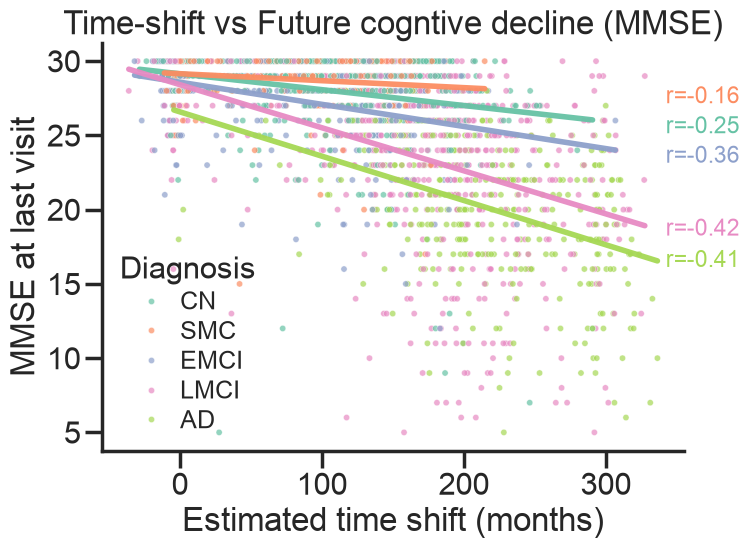

In [77]:
# Correlation between estimated time shift and MMSE at last visit
# Stratified by diagnosis group

# Build participant-level correlation dataframe
if "df_subjects" not in dir():
    raise RuntimeError("Run the subject summary cell first to create df_subjects.")

if "time_shift_by_subject" not in dir():
    raise RuntimeError("Run the time-shift cell first to create time_shift_by_subject.")

df_corr = pd.DataFrame(
    {
        "participant_id": list(time_shift_by_subject.keys()),
        "time_shift_months": list(time_shift_by_subject.values()),
    }
)

df_corr = df_corr.merge(
    df_subjects[[
        "participant_id",
        "diagnosis_group",
        "MMSE_baseline",
        "MMSE_last_visit",
    ]],
    on="participant_id",
    how="left",
)

df_corr = df_corr.dropna(subset=["diagnosis_group", "time_shift_months", "MMSE_last_visit"])

# Remove MMSE outliers for correlation analysis
n_before_filter = len(df_corr)
df_corr = df_corr[df_corr["MMSE_last_visit"] >= 5].copy()
print(f"Excluded {n_before_filter - len(df_corr)} participants with MMSE_last_visit < 5.")

hue_order = ["CN", "SMC", "EMCI", "LMCI", "AD"]
palette = dict(zip(hue_order, sns.color_palette("Set2", n_colors=len(hue_order))))

fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=df_corr,
    x="time_shift_months",
    y="MMSE_last_visit",
    hue="diagnosis_group",
    hue_order=hue_order,
    palette=palette,
    alpha=0.7,
    s=20,
    ax=ax,
)

# Add per-group linear trend lines and r annotations
x_annot = df_corr["time_shift_months"].max()
for group in hue_order:
    df_group = df_corr[df_corr["diagnosis_group"] == group]
    if len(df_group) < 2 or df_group["time_shift_months"].nunique() <= 1:
        continue

    r = df_group["MMSE_last_visit"].corr(df_group["time_shift_months"])

    sns.regplot(
        data=df_group,
        x="time_shift_months",
        y="MMSE_last_visit",
        scatter=False,
        ci=None,
        color=palette[group],
        line_kws={"linewidth": 4, "alpha": 0.95},
        ax=ax,
    )

    # Annotate r value at the right end of the trend line
    coeffs = np.polyfit(df_group["time_shift_months"], df_group["MMSE_last_visit"], 1)
    y_annot = np.polyval(coeffs, x_annot)
    ax.annotate(
        f"r={r:.2f}",
        xy=(x_annot, y_annot),
        xytext=(6, 0),
        textcoords="offset points",
        color=palette[group],
        fontsize="x-small",
        va="center",
        ha="left",
    )

ax.set_xlabel("Estimated time shift (months)")
ax.set_ylabel("MMSE at last visit")
ax.set_title("Time-shift vs Future cogntive decline (MMSE)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Diagnosis", frameon=False, fontsize=18, title_fontsize=22, loc="lower left",
          borderpad=0.2, handlelength=1.5, handletextpad=0.4, labelspacing=0.25)

fig.tight_layout()

# Per-group Pearson correlations summary
corr_summary = (
    df_corr.groupby("diagnosis_group")
    .agg(
        n=("MMSE_last_visit", "size"),
        pearson_r=("MMSE_last_visit", lambda s: s.corr(df_corr.loc[s.index, "time_shift_months"])),
    )
    .reindex(hue_order)
)
print(corr_summary)


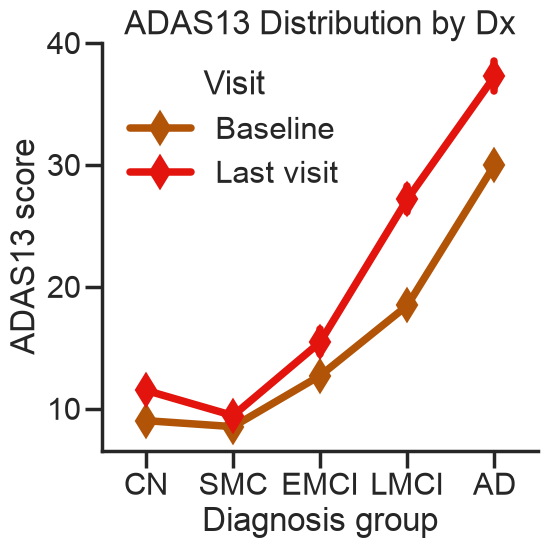

In [75]:

# Plot ADAS13 distribution at baseline and last visit stratified by diagnosis group

df_adas_long = df_subjects.melt(
    id_vars=["participant_id", "diagnosis_group"],
    value_vars=["ADAS13_baseline", "ADAS13_last_visit"],
    var_name="visit_type",
    value_name="ADAS13",
)
df_adas_long = df_adas_long.dropna(subset=["ADAS13", "diagnosis_group"])
df_adas_long["visit_type"] = df_adas_long["visit_type"].map(
    {"ADAS13_baseline": "Baseline", "ADAS13_last_visit": "Last visit"}
)

hue_order = ["CN", "SMC", "EMCI", "LMCI", "AD"]

fig, ax = plt.subplots(figsize=(6, 6))

sns.pointplot(
    data=df_adas_long,
    x="diagnosis_group",
    y="ADAS13",
    hue="visit_type",
    order=hue_order,
    marker="d",
    hue_order=["Baseline", "Last visit"],
    ax=ax,
    palette={"Baseline": "#B15408", "Last visit": "#E2140D"},
)

ax.set_xlabel("Diagnosis group")
ax.set_ylabel("ADAS13 score")
ax.set_title("ADAS13 Distribution by Dx")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Visit", frameon=False)

fig.tight_layout()


Excluded 5 participants with ADAS13_last_visit > 80.
                   n  pearson_r
diagnosis_group                
CN               510   0.315842
SMC              292   0.144848
EMCI             382   0.434213
LMCI             633   0.461257
AD               370   0.408092


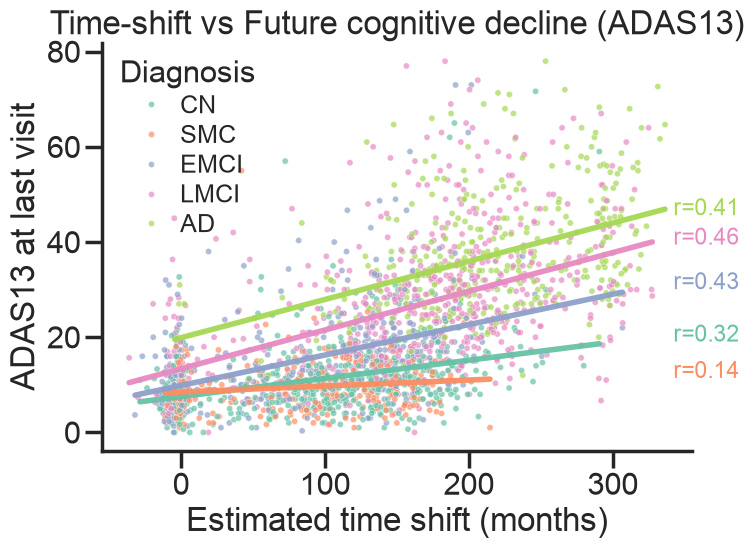

In [78]:
# Correlation between estimated time shift and ADAS13 at last visit
# Stratified by diagnosis group

df_corr_adas = pd.DataFrame(
    {
        "participant_id": list(time_shift_by_subject.keys()),
        "time_shift_months": list(time_shift_by_subject.values()),
    }
)

df_corr_adas = df_corr_adas.merge(
    df_subjects[["participant_id", "diagnosis_group", "ADAS13_baseline", "ADAS13_last_visit"]],
    on="participant_id",
    how="left",
)

df_corr_adas = df_corr_adas.dropna(subset=["diagnosis_group", "time_shift_months", "ADAS13_last_visit"])

# Remove ADAS13 outliers for correlation analysis
n_before_filter = len(df_corr_adas)
df_corr_adas = df_corr_adas[df_corr_adas["ADAS13_last_visit"] <= 80].copy()
print(f"Excluded {n_before_filter - len(df_corr_adas)} participants with ADAS13_last_visit > 80.")

hue_order = ["CN", "SMC", "EMCI", "LMCI", "AD"]
palette = dict(zip(hue_order, sns.color_palette("Set2", n_colors=len(hue_order))))

fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=df_corr_adas,
    x="time_shift_months",
    y="ADAS13_last_visit",
    hue="diagnosis_group",
    hue_order=hue_order,
    palette=palette,
    alpha=0.7,
    s=20,
    ax=ax,
)

# Add per-group linear trend lines and r annotations
x_annot = df_corr_adas["time_shift_months"].max()
for group in hue_order:
    df_group = df_corr_adas[df_corr_adas["diagnosis_group"] == group]
    if len(df_group) < 2 or df_group["time_shift_months"].nunique() <= 1:
        continue

    r = df_group["ADAS13_last_visit"].corr(df_group["time_shift_months"])

    sns.regplot(
        data=df_group,
        x="time_shift_months",
        y="ADAS13_last_visit",
        scatter=False,
        ci=None,
        color=palette[group],
        line_kws={"linewidth": 4, "alpha": 0.95},
        ax=ax,
    )

    coeffs = np.polyfit(df_group["time_shift_months"], df_group["ADAS13_last_visit"], 1)
    y_annot = np.polyval(coeffs, x_annot)
    ax.annotate(
        f"r={r:.2f}",
        xy=(x_annot, y_annot),
        xytext=(6, 0),
        textcoords="offset points",
        color=palette[group],
        fontsize="x-small",
        va="center",
        ha="left",
    )

ax.set_xlabel("Estimated time shift (months)")
ax.set_ylabel("ADAS13 at last visit")
ax.set_title("Time-shift vs Future cognitive decline (ADAS13)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Diagnosis", frameon=False, fontsize=18, title_fontsize=22, loc="upper left",
          borderpad=0.2, handlelength=1.5, handletextpad=0.4, labelspacing=0.25)

fig.tight_layout()

# Per-group Pearson correlations summary
corr_summary_adas = (
    df_corr_adas.groupby("diagnosis_group")
    .agg(
        n=("ADAS13_last_visit", "size"),
        pearson_r=("ADAS13_last_visit", lambda s: s.corr(df_corr_adas.loc[s.index, "time_shift_months"])),
    )
    .reindex(hue_order)
)
print(corr_summary_adas)


# Not used

In [ ]:
from pathlib import Path

import pandas as pd

dpath_results = "/data/origami/michelle/projects/fl-prog/results/latest"
tags = ["adni_iid", "adni_iid_train", "adni_noniid", "adni_noniid_train"]

dfs_metrics = {}
for tag in tags:
    fpath_metrics = Path(dpath_results) / tag / f"{tag}-metrics.tsv"
    df_metrics = pd.read_csv(fpath_metrics, sep="\t")
    dfs_metrics[tag] = df_metrics

df_metrics = pd.concat(dfs_metrics, names=["tag", "to_drop"])
df_metrics.index = df_metrics.index.droplevel("to_drop")
df_metrics

,setup,set_name,col_biomarker,metric,score
tag,,,,,
adni_iid,federated,train,entorhinal_thickness,r2_score,0.488760
adni_iid,federated,train,entorhinal_thickness,mean_squared_error,0.066807
adni_iid,federated,train,inferiorparietal_thickness,r2_score,0.657212
adni_iid,federated,train,inferiorparietal_thickness,mean_squared_error,0.050746
adni_iid,federated,train,middletemporal_thickness,r2_score,0.682507
...,...,...,...,...,...
adni_noniid_train,centralized,test,middletemporal_thickness,mean_squared_error,0.073315
adni_noniid_train,centralized,test,parahippocampal_thickness,r2_score,0.476905
adni_noniid_train,centralized,test,parahippocampal_thickness,mean_squared_error,0.094427


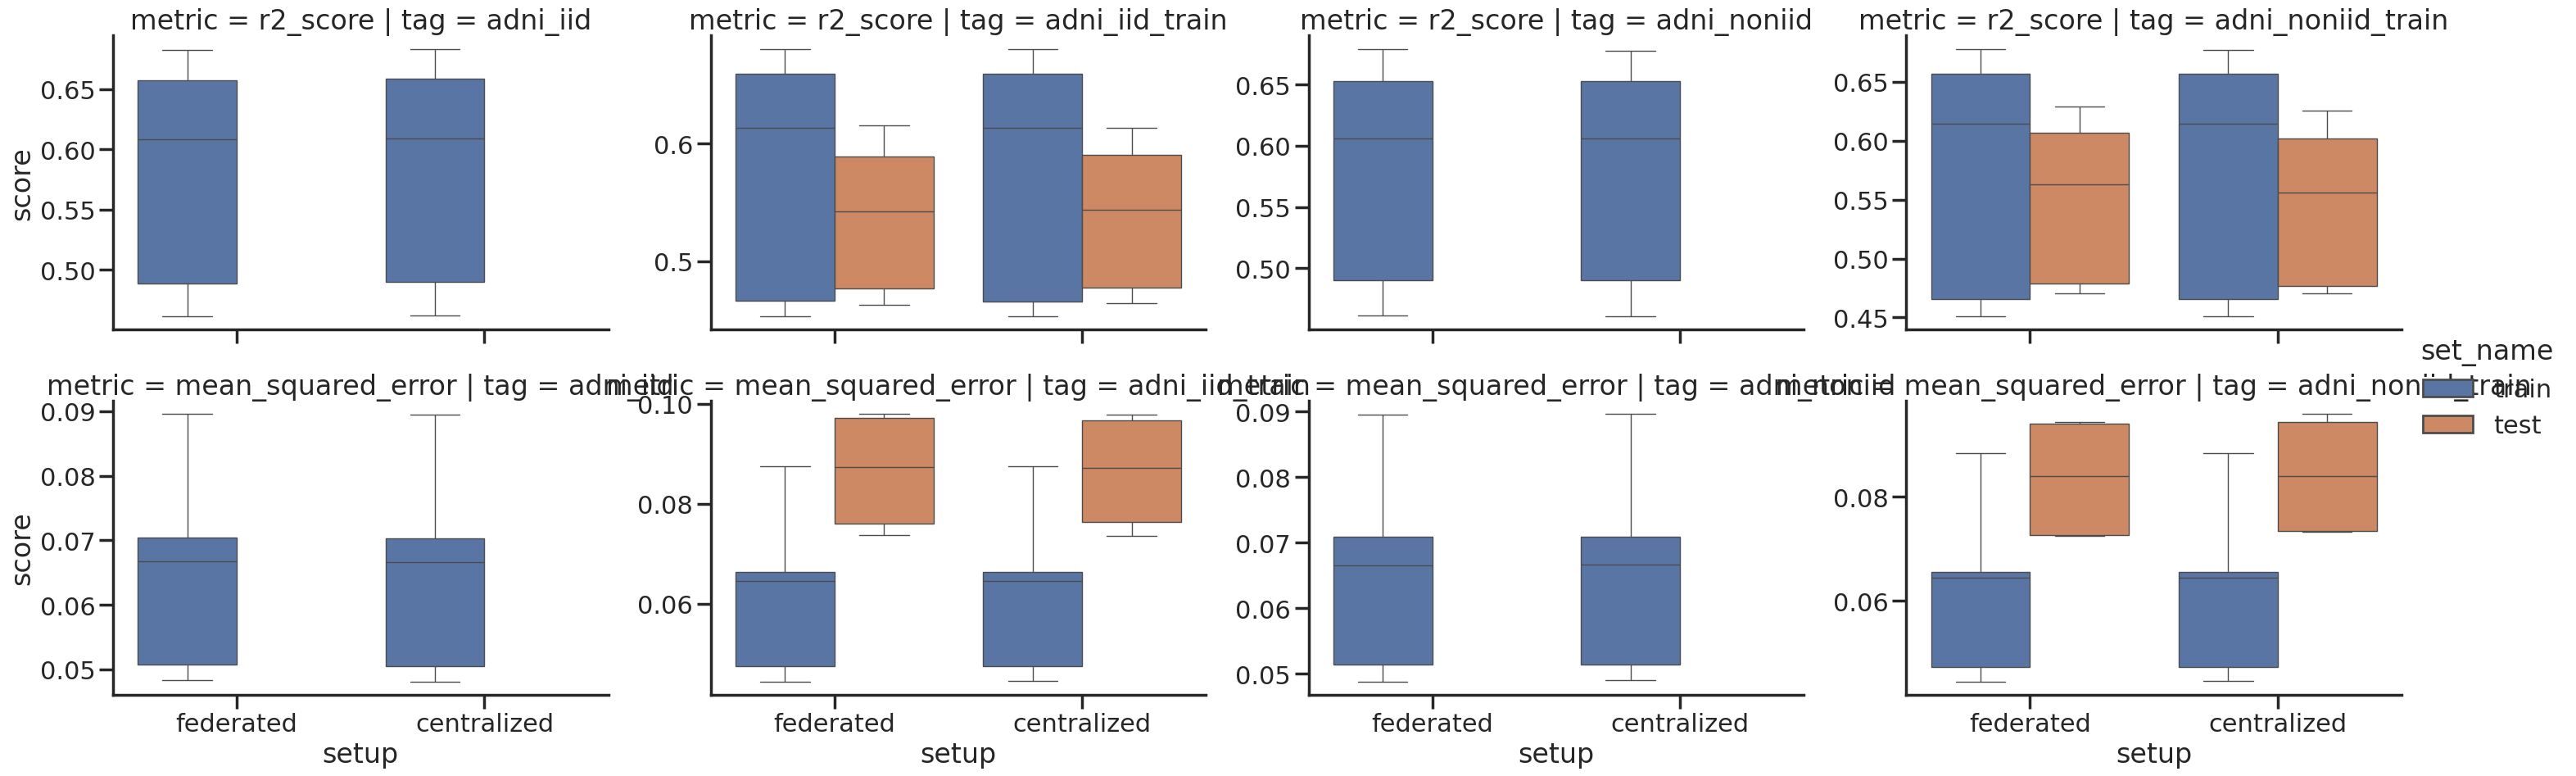

In [22]:
import seaborn as sns

sns.set_theme(context="poster", style="ticks")

sns.catplot(
    data=df_metrics,
    x="setup",
    y="score",
    hue="set_name",
    col="tag",
    kind="box",
    row="metric",
    sharey=False,
    aspect=1.5,
)